# Week 4 — Basic Backtesting

[Open this notebook in Google Colab](https://colab.research.google.com/github/KennethWYLee/FinTech/blob/main/course/04/week4_main.ipynb)

The course repository is public. If the direct Colab link is temporarily unavailable, download `week4_main.ipynb` from GitHub and upload the file to Colab.

This is the complete Week 4 lesson. It converts a signal into a position, a change in position, a gross strategy return, and a wealth path under explicit timing and execution assumptions. Every required numerical example uses fixed artificial data. Small TWSE examples connect field and session definitions to a documented real source, but they are not used to claim a profitable historical strategy.

## Core financial question

What must a backtest record so that another person can verify which information produced each position and which return interval that position was permitted to earn?

Week 3 produced point-in-time features and signals. Week 4 adds the accounting chain from signal to position, trade, gross return, and wealth. Week 5 will replace the fixed feature rule with a historically estimated prediction model and chronological update designs. Week 4 deliberately keeps transaction costs at zero and postpones full performance evaluation to Weeks 6 and 7.

Run the notebook from top to bottom. Keep the prediction written before each issue, inspect the visible output, and answer two questions with a concrete decision and supporting evidence. A successful run confirms the stated artificial accounting; it does not demonstrate a fillable real trade or future profitability.

## Observable outcome

After completing Week 4, you will produce a reproducible long-or-cash gross backtest ledger. The ledger will connect source prices, return intervals, a signal calculated after each close, the next eligible position, position changes, gross strategy returns, and wealth. It will also expose an invalid same-period implementation, handle unavailable information explicitly, state the terminal boundary, and separate an arithmetic benchmark from evidence of investment value.

## Learning objectives

After completing Week 4, you should be able to:

- write entry, exit, holding, cash, position-limit, and execution assumptions before calculating returns;
- distinguish a signal, position, trade, holding, asset return, strategy return, and wealth;
- apply the required signal-to-position lag and identify the first eligible return interval;
- verify row-level accounting identities and reject same-period look-ahead bias;
- state missing-data and terminal-boundary rules without silently inventing returns; and
- reproduce a one-asset ledger and a small specified-holdings portfolio calculation without introducing costs or full performance claims.

## Before you begin

Complete Week 3 or be able to state when a signal becomes available. Use Google Colab or a local Jupyter environment with Python, `numpy`, `pandas`, and `matplotlib`. No internet access or online market data is required. All artificial returns are decimal returns; percentages are used only for display.

Each issue contains a concept, a documented real-source connection with a narrow claim boundary, an execution prediction, a complete code example with visible output, an interpretation, and two discussion questions. Common troubleshooting and completion evidence appear once near the end.

# Navigation through the twenty issues

The issues follow the order in which a defensible backtest is built and audited.

| Section | Issues | Main decision | Object carried forward |
|---|---:|---|---|
| Written design and time boundaries | 1–4 | What does each row mean, and which later interval may a signal affect? | Strategy specification, interval table, object roles, and lag rule |
| Positions and trades | 5–9 | How are unavailable signals, entries, exits, execution assumptions, limits, and position changes represented? | Valid position and trade columns |
| Returns, wealth, and accounting | 10–13 | Which asset return belongs to each position, and do the ledger identities reconcile? | Gross strategy return and wealth |
| Failure cases and boundary choices | 14–16 | How are same-period bias, missing data, and the final boundary exposed? | Rejected implementation and explicit policies |
| Comparison, holdings, and reproducibility | 17–20 | What can a gross benchmark, specified holdings, and a complete audit support? | Reproducible gross ledger and claim boundary |

```text
Week 3 point-in-time signal
        ↓ one stated execution boundary
position held during a later return interval
        ↓ change in position
trade record
        ↓ position × same-interval asset return
gross strategy return
        ↓ compound from initial wealth 1
gross wealth
```

Transaction costs, bid-ask spread, slippage, execution delay sensitivity, and net returns begin in Week 6. Annualized performance, risk, drawdown, uncertainty, and overfitting audits are developed in Week 7.

# Preparation and common assumptions

The required examples use one artificial observation per business-day label. The labels are not an exchange calendar. A signal is calculated after the closing boundary of row $t$. Under the classroom discrete-time assumption, that signal determines the position for the next return interval ending at row $t+1$.

The required strategy is long or cash. Position 1 means one unit of portfolio wealth is exposed to the artificial asset; position 0 means zero-return cash. Short selling and leverage are not permitted. Week 4 uses zero transaction costs and reports gross results. The final row reports the position held for its return interval and does not force liquidation.

For each integrated case, complete this concise record once:

```text
Signal and availability time:
Decision boundary:
Earliest permitted execution boundary:
Return interval earned by position at row t:
Entry and exit rule:
Permitted positions and cash-return rule:
Missing-signal and missing-return rule:
Terminal-position rule:
Transaction-cost status:
One conclusion the ledger cannot support:
```

In [1]:
from importlib.metadata import version
import platform

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 24)
pd.set_option("display.width", 150)
plt.rcParams.update(
    {
        "figure.figsize": (7.6, 3.8),
        "figure.dpi": 110,
        "axes.grid": True,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


def show_figure_with_alt_text(figure, alt_text):
    if not isinstance(alt_text, str) or not alt_text.strip():
        raise ValueError("Figure alternative text must be a nonempty string.")
    display(figure, metadata={"image/png": {"alt": alt_text.strip()}})
    plt.close(figure)


environment = pd.Series(
    {
        "Python interface": "Jupyter kernel",
        "Python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "matplotlib": mpl.__version__,
    },
    name="Value",
)
display(environment.rename_axis("Environment item").to_frame())

,Value
Environment item,
Python interface,Jupyter kernel
Python,3.12.9
numpy,2.2.6
pandas,2.2.3
matplotlib,3.10.8


## Issue 1 — What must be fixed before a backtest starts?


A backtest is an implementation of a written decision rule, not merely a loop over prices. Before any return is calculated, the design must state the data frequency, signal time, decision time, execution boundary, holding return, permitted positions, cash return, entry and exit rules, position limits, missing-information rule, cost status, and terminal boundary.

These choices determine which return a position can earn. If they are filled in after the results are inspected, the design has already used evaluation evidence. The Week 4 specification below is deliberately narrow: one artificial asset, a signal known after a row's close, next-interval exposure, long or cash, zero cash return, and no forced liquidation.

The specification is not evidence that the assumed execution price would be available in a real market. It is the claim that the artificial ledger will implement and test for internal consistency.


#### Connection to a documented real source


The TWSE trading-mechanism page states regular-session order and trading boundaries. It can support a real session-time record, but it does not choose the feature, entry rule, execution assumption, or terminal rule for a strategy. Those remain analyst decisions that must be written before testing.


### Before running the example


Predict which specification fields would change if execution moved from the next return interval to the same row's closing price. Mark that design invalid if the signal is known only after that close.

In [2]:
strategy_specification = pd.DataFrame(
    [
        ("Data frequency", "One artificial observation per business-day label"),
        ("Signal time", "After the closing boundary of row t"),
        ("Decision time", "After the row-t signal is calculated"),
        ("Earliest execution", "Boundary before the return interval ending at t+1"),
        ("Holding return", "Artificial close-to-close return for the held interval"),
        ("Permitted positions", "0 for cash or 1 for long exposure"),
        ("Entry rule", "Position changes from 0 to 1 after a preceding signal of 1"),
        ("Exit rule", "Position changes from 1 to 0 after a preceding signal of 0"),
        ("Cash return", "0 in Week 4"),
        ("Unavailable signal", "Remain in cash"),
        ("Transaction costs", "0; gross backtest only"),
        ("Terminal boundary", "Report the final position; do not force liquidation"),
    ],
    columns=["Design field", "Week 4 rule"],
)
display(strategy_specification.style.hide(axis="index").set_caption("Prespecified Week 4 strategy rules"))

required_spec_fields = {
    "Signal time", "Decision time", "Earliest execution", "Holding return",
    "Permitted positions", "Entry rule", "Exit rule", "Cash return",
    "Unavailable signal", "Transaction costs", "Terminal boundary",
}
assert required_spec_fields.issubset(set(strategy_specification["Design field"]))

Design field,Week 4 rule
Data frequency,One artificial observation per business-day label
Signal time,After the closing boundary of row t
Decision time,After the row-t signal is calculated
Earliest execution,Boundary before the return interval ending at t+1
Holding return,Artificial close-to-close return for the held interval
Permitted positions,0 for cash or 1 for long exposure
Entry rule,Position changes from 0 to 1 after a preceding signal of 1
Exit rule,Position changes from 1 to 0 after a preceding signal of 0
Cash return,0 in Week 4
Unavailable signal,Remain in cash


### Interpret the output


The table makes the return assignment falsifiable. A row-$t$ signal cannot earn a return that ended at the row-$t$ close because both the signal calculation and decision occur afterward. The first eligible exposure is the next interval under the stated artificial boundary.

Zero costs are a scope choice, not a realistic market estimate. The reported wealth later in this notebook is therefore gross. The terminal rule also matters: forcing a final sale would add a trade that the current specification does not contain.


### Discussion questions

1. A team writes only `buy when momentum is positive`. Identify at least six missing decisions that prevent another person from reconstructing the return ledger. For two of them, give alternative choices that would change the calculated result even with identical prices and signals.
2. The team calculates its signal after the 13:30 close and assumes a fill at that same 13:30 closing price. Decide whether the assumption is compatible with the written time order. State the earliest boundary that could replace it and the additional real execution evidence that would still be needed.

## Issue 2 — Which interval does a return row represent?


A return stored on row $t$ normally describes the change between two boundaries, not an event that begins and ends on row $t$. In this lesson, `asset_return[t]` is the price change from row $t-1$ to row $t$. A signal calculated after the row-$t$ close is therefore too late to earn that return.

The safest audit expands each return into a beginning boundary, ending boundary, and observation pair. Once the interval is visible, the question is not whether the code contains a shift but whether the position was fixed before the interval began.

The real-source example below uses only two TWSE closing observations to illustrate endpoint labeling. It does not assign a signal or construct a historical strategy.


#### Connection to a documented real source


The TWSE daily report for security 2330 records a close of 320.00 on 2020-02-24 and 322.00 on 2020-02-25. Those values define a price-return interval ending on February 25 once field, unit, and corporate-action assumptions are stated. The report does not say that a signal calculated after the February 25 close could earn that interval.


### Before running the example


Predict the return from 320 to 322 and identify the latest time at which a position would have to be fixed to earn that close-to-close interval under the classroom convention.

In [3]:
interval_example = pd.DataFrame(
    {
        "Beginning boundary": ["2020-02-24 close", "Artificial row A close"],
        "Ending boundary": ["2020-02-25 close", "Artificial row B close"],
        "Beginning price": [320.0, 100.0],
        "Ending price": [322.0, 103.0],
    },
    index=["TWSE source-reading example", "Artificial example"],
)
interval_example["Simple price return"] = (
    interval_example["Ending price"] / interval_example["Beginning price"] - 1
)
display(interval_example.style.format({"Simple price return": "{:.4%}"}).set_caption("Returns with explicit beginning and ending boundaries"))

assert np.isclose(interval_example.loc["TWSE source-reading example", "Simple price return"], 322 / 320 - 1)
assert np.isclose(interval_example.loc["Artificial example", "Simple price return"], 0.03)

,Beginning boundary,Ending boundary,Beginning price,Ending price,Simple price return
TWSE source-reading example,2020-02-24 close,2020-02-25 close,320.000000,322.000000,0.6250%
Artificial example,Artificial row A close,Artificial row B close,100.000000,103.000000,3.0000%


### Interpret the output


The TWSE price return is 0.625%, and the artificial return is 3.0%. Both are labeled by an ending boundary but require the preceding price. A position that earns either return must be established no later than the beginning boundary under this simplified close-to-close convention.

The calculation is price-only and ignores distributions, costs, and execution feasibility. Its purpose is to make the interval visible before the signal is aligned.


### Discussion questions

1. A table labels a 2% return on April 3 but omits the beginning price date. Construct two different beginning boundaries that could both lead to a row labeled April 3. Explain why a signal-to-return audit cannot continue until the intended interval is identified.
2. For the TWSE 320-to-322 example, assume a signal is calculated only after the February 25 close. Reject the claim that the signal earned 0.625%, then name the first later close-to-close interval that could be evaluated if the position begins before the next session's return.

## Issue 3 — How are signal, position, trade, return, and wealth different?


The central backtest objects have different financial meanings. A signal is the output of a rule. A position is the exposure held during a return interval. A trade is a change in position at a stated boundary. An asset return belongs to the asset over an interval. A strategy return combines the position and same-interval asset return. Wealth compounds the ordered strategy returns from an initial value.

Using one name such as `strategy` for all of these objects hides timing and accounting mistakes. A complete ledger keeps separate columns and records when each becomes known.

The following table is a role audit rather than a performance calculation.


#### Connection to a documented real source


TWSE reports market fields and session boundaries, while pandas documents calculations such as `shift`, `diff`, and `cumprod`. Neither source makes these objects interchangeable. The financial design determines the meaning of each column; software only applies the stated operation.


### Before running the example


Predict which objects are states and which are changes or outcomes. Identify the only multiplication that produces the Week 4 gross strategy return.

In [4]:
object_roles = pd.DataFrame(
    [
        ("signal_at_close", "Rule output", "After row-t close", "No"),
        ("position", "Exposure held during one later return interval", "Before the interval", "Yes"),
        ("trade", "Absolute change in exposure", "At the position-change boundary", "No"),
        ("asset_return", "Asset price change over one interval", "At interval end", "No"),
        ("strategy_return_gross", "Position times same-interval asset return", "At interval end", "No"),
        ("strategy_wealth_gross", "Compounded gross strategy returns", "After each interval", "Yes"),
    ],
    columns=["Ledger object", "Financial meaning", "Relevant time", "State variable"],
)
display(object_roles.style.hide(axis="index").set_caption("Distinct objects in a basic backtest"))

assert object_roles["Ledger object"].is_unique
assert set(object_roles.loc[object_roles["State variable"] == "Yes", "Ledger object"]) == {"position", "strategy_wealth_gross"}

Ledger object,Financial meaning,Relevant time,State variable
signal_at_close,Rule output,After row-t close,No
position,Exposure held during one later return interval,Before the interval,Yes
trade,Absolute change in exposure,At the position-change boundary,No
asset_return,Asset price change over one interval,At interval end,No
strategy_return_gross,Position times same-interval asset return,At interval end,No
strategy_wealth_gross,Compounded gross strategy returns,After each interval,Yes


### Interpret the output


Position and wealth are state variables: each describes a condition carried at a boundary. Trade and return are changes over a boundary or interval. The gross strategy return is `position × asset_return` after both have been aligned to the same interval.

A signal is not automatically a position because the execution rule may delay, limit, or reject the requested exposure. Week 4 uses a direct long-or-cash mapping only after a one-row lag.


### Discussion questions

1. A student's ledger contains only `signal`, `return`, and `equity`. Identify the missing object needed to prove which exposure earned each return and the missing object needed to count changes in exposure. Explain one error that each omission could conceal.
2. A signal changes from 0 to 1, but a position limit prevents exposure from exceeding 0.5. State the signal, resulting position, trade size, and formula for gross strategy return if the asset return is 2%. Explain why copying the signal directly into the position would violate the design.

## Issue 4 — How does an after-close signal become the next position?


Under the Week 4 boundary, the signal on row $t-1$ determines the position held during the return interval ending on row $t$. The required relation is $p_t=s_{t-1}$. A one-row positive shift in pandas implements this relation only because the table has already been sorted and each row represents one consecutive artificial interval.

The example deliberately shows both the valid lagged position and an invalid same-row position. The validity comes from the written time order, not from the fact that one column uses `shift(1)`.

The initial position is cash because no preceding signal exists.


#### Connection to a documented real source


Pandas documents that `shift(1)` moves stored values to a later row. The TWSE session boundary explains why an after-close value cannot act before that close. A real implementation must still verify holidays, missing sessions, and the actual execution event rather than assuming every row shift is one tradable interval.


### Before running the example


For signals missing, 1, 0, 1 on rows A–D, predict the valid positions on all four rows and identify the first row that can hold a long position.

In [5]:
lag_demo = pd.DataFrame(
    {
        "signal_at_close": [np.nan, 1.0, 0.0, 1.0],
        "asset_return": [np.nan, 0.02, -0.01, 0.03],
    },
    index=pd.Index(["A", "B", "C", "D"], name="Row"),
)
lag_demo["valid_position"] = lag_demo["signal_at_close"].shift(1).fillna(0.0)
lag_demo["invalid_same_row_position"] = lag_demo["signal_at_close"].fillna(0.0)
lag_demo["valid_gross_return"] = (lag_demo["valid_position"] * lag_demo["asset_return"]).fillna(0.0)
display(lag_demo.style.format({"asset_return": "{:.2%}", "valid_gross_return": "{:.2%}"}).set_caption("Signal-to-position lag on four artificial rows"))

assert lag_demo["valid_position"].tolist() == [0.0, 0.0, 1.0, 0.0]
assert lag_demo.loc["C", "valid_gross_return"] == -0.01

,signal_at_close,asset_return,valid_position,invalid_same_row_position,valid_gross_return
Row,,,,,
A,nan,nan%,0.000000,0.000000,0.00%
B,1.000000,2.00%,0.000000,1.000000,0.00%
C,0.000000,-1.00%,1.000000,0.000000,-1.00%
D,1.000000,3.00%,0.000000,1.000000,0.00%


### Interpret the output


The first long position appears on row C because row B is the first row with a signal of 1. That position earns the row-C asset return of −1.0%. The row-C signal is 0 and affects row D, not row C.

The invalid column reacts one row too early. It may produce a numerically attractive or unattractive result; either direction is irrelevant because it violates the time order.


### Discussion questions

1. Signals on rows 1–5 are `missing, 0, 1, 1, 0`. Write the valid positions and identify every row on which valid and same-row positions differ. For the first difference, state which signal actually controls the interval.
2. A dataset skips one expected market session. Decide whether `shift(1)` still represents the next eligible execution interval. Specify the date, session, or timestamp checks required before retaining the one-row lag.

## Issue 5 — What happens before the first signal is available?


An unavailable signal is not the same as a signal of zero. The former means the feature history or source value does not yet exist; the latter is an observed rule output. Week 4 must nevertheless choose an initial position. The required classroom rule remains in zero-return cash until a preceding signal is available.

This initialization prevents the notebook from inventing a long position. It does not erase the missing signal: the signal column remains missing so that the reason for initial cash can be audited.

Alternative initialization rules would define different strategies and must be chosen before evaluation.


#### Connection to a documented real source


An official source can begin after the requested analysis start or omit a session. Neither TWSE data nor pandas instructs an analyst to convert unavailable history into a neutral signal. The source supplies observations; the strategy specification supplies the initialization rule.


### Before running the example


Predict the signal and position columns during the first five rows of a five-session momentum rule. Explain why signal remains missing while position is explicitly zero.

In [6]:
initialization_demo = pd.DataFrame(
    {
        "mom_5": [np.nan, np.nan, np.nan, np.nan, np.nan, 0.02, -0.01],
    },
    index=pd.date_range("2026-03-02", periods=7, freq="D"),
)
initialization_demo["signal_at_close"] = np.where(
    initialization_demo["mom_5"].isna(),
    np.nan,
    np.where(initialization_demo["mom_5"] > 0, 1.0, 0.0),
)
initialization_demo["position"] = initialization_demo["signal_at_close"].shift(1).fillna(0.0)
display(initialization_demo.style.format({"mom_5": "{:.2%}"}).set_caption("Missing feature history and explicit initial cash"))

assert initialization_demo["signal_at_close"].iloc[:5].isna().all()
assert initialization_demo["position"].iloc[:6].eq(0.0).all()
assert initialization_demo["position"].iloc[6] == 1.0

,mom_5,signal_at_close,position
2026-03-02 00:00:00,nan%,nan,0.000000
2026-03-03 00:00:00,nan%,nan,0.000000
2026-03-04 00:00:00,nan%,nan,0.000000
2026-03-05 00:00:00,nan%,nan,0.000000
2026-03-06 00:00:00,nan%,nan,0.000000
2026-03-07 00:00:00,2.00%,1.000000,0.000000
2026-03-08 00:00:00,-1.00%,0.000000,1.000000


### Interpret the output


The first five signals remain missing because five-session momentum is unavailable. The signal on the sixth row becomes 1, but the position stays in cash on that row because the signal is known only afterward. The seventh row is the first long interval.

The position column contains zeros during initialization because the strategy explicitly chooses cash. That decision must not be mistaken for observed zero signals.


### Discussion questions

1. A team fills unavailable momentum with zero before applying its rule. Compare the resulting signal history with the missing-preserving version and identify the exact rows on which the backtest claims to have made decisions without a valid feature.
2. Choose between initial cash and initial long exposure for a new strategy. State what prior information would justify each choice and explain why selecting the better final result after testing would create a different, data-chosen initialization rule.

## Issue 6 — What exactly triggers an entry and an exit?


An entry is a change from cash to long exposure. An exit is a change from long exposure to cash. The signal value alone does not identify either event because a repeated signal can leave the position unchanged.

Under the Week 4 rule, entries and exits are detected from consecutive positions after the signal has been lagged. A change from 0 to 1 has signed change +1; a change from 1 to 0 has signed change −1. The absolute change is 1 for either event and 0 when the position is held.

This event definition will later support turnover and costs, but Week 4 does not charge either event.


#### Connection to a documented real source


The TWSE distinguishes orders from executions and defines session boundaries. A classroom position change is therefore only an accounting event under the stated execution assumption; it is not proof that a real order was filled at the assumed boundary.


### Before running the example


For positions `0, 0, 1, 1, 0, 1`, predict the signed changes, identify the two entries and one exit, and distinguish those three events from the number of long holding intervals.

In [7]:
event_demo = pd.DataFrame(
    {"position": [0.0, 0.0, 1.0, 1.0, 0.0, 1.0]},
    index=pd.Index(range(6), name="Row"),
)
event_demo["signed_position_change"] = event_demo["position"].diff().fillna(event_demo["position"])
event_demo["absolute_position_change"] = event_demo["signed_position_change"].abs()
event_demo["event"] = np.select(
    [event_demo["signed_position_change"] > 0, event_demo["signed_position_change"] < 0],
    ["Entry", "Exit"],
    default="Hold",
)
display(event_demo.style.hide(axis="index").set_caption("Entries, exits, and held positions"))

event_summary = pd.Series(
    {
        "entries": int((event_demo["event"] == "Entry").sum()),
        "exits": int((event_demo["event"] == "Exit").sum()),
        "long_intervals": int(event_demo["position"].sum()),
        "position_changes": int((event_demo["absolute_position_change"] > 0).sum()),
    },
    name="Count",
)
display(event_summary.to_frame())
assert event_summary.to_dict() == {"entries": 2, "exits": 1, "long_intervals": 3, "position_changes": 3}

position,signed_position_change,absolute_position_change,event
0.000000,0.000000,0.000000,Hold
0.000000,0.000000,0.000000,Hold
1.000000,1.000000,1.000000,Entry
1.000000,0.000000,0.000000,Hold
0.000000,-1.000000,1.000000,Exit
1.000000,1.000000,1.000000,Entry


,Count
entries,2
exits,1
long_intervals,3
position_changes,3


### Interpret the output


Rows 2 and 5 are entries, row 4 is an exit, and row 3 is a hold. Three position changes and three long intervals happen to have the same count in this example, but they measure different objects and need not match on another path.

The first row is treated as an initial state, not an entry, because it begins in cash. A different initial-position rule would change this boundary treatment.


### Discussion questions

1. Signals after close are `1, 1, 0, 0, 1`, and the initial position is cash. Derive the lagged positions, label every entry and exit, and explain why the second consecutive signal of 1 is not another entry.
2. A strategy begins the sample already long. Decide whether the first row should count as an entry, an inherited holding, or an unresolved pre-sample event. State how each convention changes trade counts and what the report must disclose.

## Issue 7 — Which execution boundary connects a decision to a holding return?


An execution assumption connects the decision time with the beginning of the return interval. A next-open design and a next-close design do not earn the same holding return, even when they use the same after-close signal. The corresponding open-to-close, close-to-close, or close-to-next-close prices must be recorded consistently.

The artificial table compares two possible next-session designs without selecting one. The purpose is to show that an execution label changes both the required price field and the interval being evaluated.

Real fillability requires order type, liquidity, spread, queue, and market-mechanism evidence that Week 4 does not provide.


#### Connection to a documented real source


TWSE documents regular-session order placement and trading hours, including opening and closing call auctions. This supports distinguishing market boundaries. It does not guarantee that a hypothetical order receives the published opening or closing price.


### Before running the example


Assume a signal is known after day 0 closes at 100, the next day opens at 101 and closes at 103. Predict the next-open-to-close and next-close-to-following-close returns, and state which later price is still needed for the second design.

In [8]:
execution_example = pd.DataFrame(
    [
        {
            "Design": "Next open, exit next close",
            "Decision known": "After day 0 close",
            "Entry price": 101.0,
            "Exit price": 103.0,
            "Holding return": 103.0 / 101.0 - 1,
        },
        {
            "Design": "Next close, exit following close",
            "Decision known": "After day 0 close",
            "Entry price": 103.0,
            "Exit price": 102.0,
            "Holding return": 102.0 / 103.0 - 1,
        },
    ]
)
display(execution_example.style.format({"Holding return": "{:.3%}"}).hide(axis="index").set_caption("Two artificial execution and holding-return definitions"))

assert np.isclose(execution_example.loc[0, "Holding return"], 103 / 101 - 1)
assert np.isclose(execution_example.loc[1, "Holding return"], 102 / 103 - 1)

Design,Decision known,Entry price,Exit price,Holding return
"Next open, exit next close",After day 0 close,101.000000,103.000000,1.980%
"Next close, exit following close",After day 0 close,103.000000,102.000000,-0.971%


### Interpret the output


The next-open design earns approximately 1.980% from 101 to 103. The next-close design begins later at 103 and earns approximately −0.971% to the following close of 102. These are different strategies, not two estimates of one return.

The table uses hypothetical prices and assumes full execution. Week 6 will add execution delay and cost sensitivity, but even that will not prove a real fill without order-level evidence.


### Discussion questions

1. A team describes its strategy as `trade next day` but calculates close-to-close returns. List the alternative execution boundaries hidden by that phrase and identify the exact price fields required to make one design reproducible.
2. The same signal produces a positive next-open-to-close return and a negative next-close-to-following-close return. Decide whether this difference is evidence that one implementation is better, or evidence that the strategy definition changed. Defend the answer before considering performance.

## Issue 8 — How are long-or-cash position limits enforced?


A valid long-or-cash position must be finite and belong to the permitted set `{0, 1}`. A raw signal of 2, −1, or missing cannot be silently clipped or converted without a written rule. The backtest should stop on values that contradict the specification.

This issue separates validation from transformation. Validation reports whether a candidate already satisfies the design. It does not repair the candidate. A later multi-asset weighting method will use different constraints, but Week 4 uses a single scalar exposure.

Stopping on an invalid position protects every later return and wealth calculation from an undefined exposure.


#### Connection to a documented real source


Official market rules define permitted order and trading mechanisms, but a strategy's portfolio limits are separate design choices. Pandas and NumPy can test finiteness and membership; they do not decide whether short selling or leverage is financially permitted.


### Before running the example


Predict which values in `0, 1, 0.5, -1, 2, missing` pass the exact long-or-cash rule. Do not round or clip the invalid values.

In [9]:
candidate_positions = pd.Series([0.0, 1.0, 0.5, -1.0, 2.0, np.nan], name="candidate_position")
position_validation = pd.DataFrame({"candidate_position": candidate_positions})
position_validation["finite"] = np.isfinite(position_validation["candidate_position"])
position_validation["permitted_long_or_cash"] = position_validation["candidate_position"].isin([0.0, 1.0])
position_validation["decision"] = np.where(
    position_validation["finite"] & position_validation["permitted_long_or_cash"],
    "Accept",
    "Stop and inspect",
)
display(position_validation.style.hide(axis="index").set_caption("Validation without silent clipping"))

assert position_validation["decision"].tolist() == ["Accept", "Accept", "Stop and inspect", "Stop and inspect", "Stop and inspect", "Stop and inspect"]

candidate_position,finite,permitted_long_or_cash,decision
0.000000,True,True,Accept
1.000000,True,True,Accept
0.500000,True,False,Stop and inspect
-1.000000,True,False,Stop and inspect
2.000000,True,False,Stop and inspect
nan,False,False,Stop and inspect


### Interpret the output


Only 0 and 1 pass. A value of 0.5 might be valid under a different fractional-position design, but it is invalid under the exact Week 4 specification. Missing means that a position rule has not produced an exposure; it is not accepted as cash unless the initialization rule explicitly supplies zero in a separate step.

Clipping −1 to 0 or 2 to 1 would hide a contradiction between the signal mapping and the position constraint. The appropriate action is to inspect and revise the design or upstream code.


### Discussion questions

1. A model emits scores of −0.2, 0.4, and 1.3. Propose one explicit mapping to long-or-cash positions and explain why applying `clip(0, 1)` would instead create fractional exposures that violate the current specification.
2. A position column contains one value of 0.999999 because of floating-point arithmetic. Decide whether to reject it, compare with a tolerance, or trace its construction. State which choice preserves the exact discrete rule and how the accepted values should be recorded.

## Issue 9 — How is a trade measured from positions?


For a single long-or-cash asset, signed position change is $p_t-p_{t-1}$ and absolute position change is $|p_t-p_{t-1}|$. The signed value distinguishes entry from exit; the absolute value measures the size of the exposure change.

The first-row convention matters. Week 4 initializes the portfolio in cash before the sample, so the first position change is measured relative to zero. A reported trade on a later row must reconcile exactly with the two adjacent positions.

The absolute change is the quantity that Week 6 will connect to a cost rate. It is not yet a currency cost.


#### Connection to a documented real source


Pandas documents `Series.diff` as the difference from an earlier element. That operation supplies the arithmetic, while the strategy specification supplies the pre-sample position and the financial meaning of an entry or exit.


### Before running the example


For positions `0, 1, 1, 0, 0, 1`, predict the signed and absolute changes and identify which rows would later incur nonzero transaction costs.

In [10]:
trade_demo = pd.DataFrame(
    {"position": [0.0, 1.0, 1.0, 0.0, 0.0, 1.0]},
    index=pd.Index(range(6), name="Row"),
)
trade_demo["signed_trade"] = trade_demo["position"].diff().fillna(trade_demo["position"] - 0.0)
trade_demo["absolute_trade"] = trade_demo["signed_trade"].abs()
trade_demo["reconciliation"] = trade_demo["position"] - trade_demo["position"].shift(1).fillna(0.0)
display(trade_demo.style.set_caption("Position changes measured relative to initial cash"))

assert np.allclose(trade_demo["signed_trade"], trade_demo["reconciliation"])
assert trade_demo["absolute_trade"].sum() == 3.0
assert (trade_demo["absolute_trade"] > 0).sum() == 3

,position,signed_trade,absolute_trade,reconciliation
Row,,,,
0,0.000000,0.000000,0.000000,0.000000
1,1.000000,1.000000,1.000000,1.000000
2,1.000000,0.000000,0.000000,0.000000
3,0.000000,-1.000000,1.000000,-1.000000
4,0.000000,0.000000,0.000000,0.000000
5,1.000000,1.000000,1.000000,1.000000


### Interpret the output


The sequence contains an entry on row 1, an exit on row 3, and another entry on row 5. The total absolute position change is 3. This total is expressed in units of portfolio exposure, not dollars and not yet a percentage cost.

Rows with unchanged positions have zero trade even though the asset still earns a return while the position is 1. Holding exposure and changing exposure remain separate.


### Discussion questions

1. A student counts every row with position 1 as a trade. Compare that count with the rows where absolute position change is positive and explain how the error would distort Week 6 costs.
2. A sample begins with position 1 but the pre-sample position is unknown. Calculate the first-row trade under initial-cash and inherited-holding conventions. Decide which result may be reported when the pre-sample state was not recorded.

## Issue 10 — How are prices, signals, positions, and returns aligned in one ledger?


The complete ledger begins with sorted unique price rows, calculates the return ending on each row, constructs a trailing feature and after-close signal, shifts the signal once to form the position, and records the position change. Every column retains its own time meaning.

The fixed artificial path below is shared by Issues 10–20. It contains alternating return clusters so entries and exits occur, but the path was created for accounting practice rather than to represent a market process.

The first price return is missing because no earlier price exists. The gross strategy return on that row will later be zero only because the initial position is cash, not because a missing asset return is generally zero.


#### Connection to a documented real source


The TWSE daily report illustrates the real fields and trading-date labels that a future ledger might use. Pandas documents `pct_change`, which returns fractional change rather than an automatic percentage. Neither source validates the artificial signal rule or execution assumption.


### Before running the example


Predict the first valid five-session momentum row, the first available signal row, and the first row on which that signal can create a long position.

In [11]:
dates = pd.bdate_range("2026-03-02", periods=30)
artificial_returns = np.array([
    0.010, 0.008, -0.004, 0.006, 0.003,
    -0.012, -0.008, -0.005, 0.004, 0.006,
    0.009, 0.010, -0.003, -0.011, -0.007,
    0.005, 0.008, 0.012, 0.004, -0.006,
    -0.009, -0.004, 0.007, 0.011, 0.003,
    -0.002, -0.008, 0.006, 0.009,
])
prices = np.r_[100.0, 100.0 * np.cumprod(1 + artificial_returns)]

bt = pd.DataFrame({"Close": prices}, index=dates)
bt.index.name = "Date"
bt["asset_return"] = bt["Close"].pct_change(fill_method=None)
bt["mom_5"] = bt["Close"] / bt["Close"].shift(5) - 1
bt["signal_at_close"] = np.where(
    bt["mom_5"].isna(),
    np.nan,
    np.where(bt["mom_5"] > 0, 1.0, 0.0),
)
bt["position"] = bt["signal_at_close"].shift(1).fillna(0.0)
bt["signed_trade"] = bt["position"].diff().fillna(bt["position"])
bt["absolute_trade"] = bt["signed_trade"].abs()

display(bt.head(12).style.format({"asset_return": "{:.2%}", "mom_5": "{:.2%}"}).set_caption("Beginning of the shared artificial Week 4 ledger"))

first_valid = pd.Series(
    {
        "first_asset_return": bt["asset_return"].first_valid_index(),
        "first_momentum": bt["mom_5"].first_valid_index(),
        "first_signal": bt["signal_at_close"].first_valid_index(),
        "first_long_position": bt.index[bt["position"].eq(1.0)][0],
    },
    name="Date",
)
display(first_valid.to_frame())

assert bt.index.is_unique and bt.index.is_monotonic_increasing
assert bt["Close"].gt(0).all() and np.isfinite(bt["Close"]).all()
assert set(bt["signal_at_close"].dropna().unique()).issubset({0.0, 1.0})
assert set(bt["position"].unique()).issubset({0.0, 1.0})

,Close,asset_return,mom_5,signal_at_close,position,signed_trade,absolute_trade
Date,,,,,,,
2026-03-02 00:00:00,100.000000,nan%,nan%,nan,0.000000,0.000000,0.000000
2026-03-03 00:00:00,101.000000,1.00%,nan%,nan,0.000000,0.000000,0.000000
2026-03-04 00:00:00,101.808000,0.80%,nan%,nan,0.000000,0.000000,0.000000
2026-03-05 00:00:00,101.400768,-0.40%,nan%,nan,0.000000,0.000000,0.000000
2026-03-06 00:00:00,102.009173,0.60%,nan%,nan,0.000000,0.000000,0.000000
2026-03-09 00:00:00,102.315200,0.30%,2.32%,1.000000,0.000000,0.000000,0.000000
2026-03-10 00:00:00,101.087418,-1.20%,0.09%,1.000000,1.000000,1.000000,1.000000
2026-03-11 00:00:00,100.278718,-0.80%,-1.50%,0.000000,1.000000,0.000000,0.000000
2026-03-12 00:00:00,99.777325,-0.50%,-1.60%,0.000000,0.000000,-1.000000,1.000000


,Date
first_asset_return,2026-03-03
first_momentum,2026-03-09
first_signal,2026-03-09
first_long_position,2026-03-10


### Interpret the output


The first asset return appears on the second price row. Five-session momentum and the signal first appear on the sixth price row because six price endpoints are required. The first long position appears one row later because the signal is shifted to the next interval.

The table makes the different first-valid dates visible. The business-day labels do not prove that these are real exchange sessions, and the synthetic path supports no market conclusion.


### Discussion questions

1. Select the first long-position row. List the six prices used to create the controlling momentum signal, identify the signal row, and name the asset-return endpoints earned by the position. Explain every one-row boundary.
2. Delete one date from the artificial table and recompute the ledger. Decide whether the next remaining row represents the next eligible trading session or merely the next stored observation, and state what real calendar evidence would be needed to interpret the shift.

## Issue 11 — How is gross strategy return calculated?


For a single asset with cash return zero, gross strategy return on row $t$ is the position held during that interval multiplied by the asset return ending on the row: $r^{\mathrm{gross}}_{p,t}=p_t r_{a,t}$. The position and return must describe the same interval.

A cash position produces a zero strategy return even when the asset moves. A long position reproduces the asset return. The first row is set to zero only because the specified initial position is cash and no asset interval exists.

Gross means that no commission, spread, slippage, or other cost has been deducted. It is not a synonym for profit.


#### Connection to a documented real source


The TWSE report can supply documented price endpoints for a price-return calculation. The strategy position is created by the classroom rule, not by the exchange. Pandas multiplication aligns rows by index, so mismatched indexes must be detected rather than accepted silently.


### Before running the example


Predict the strategy return on the first long row and on the first later cash row. State which asset return is ignored while the position is cash.

In [12]:
bt["strategy_return_gross"] = bt["position"] * bt["asset_return"]
initial_row = bt.index[0]
if bt.loc[initial_row, "position"] == 0 and pd.isna(bt.loc[initial_row, "asset_return"]):
    bt.loc[initial_row, "strategy_return_gross"] = 0.0

gross_preview = bt[["asset_return", "signal_at_close", "position", "strategy_return_gross"]].iloc[4:15]
display(gross_preview.style.format({"asset_return": "{:.2%}", "strategy_return_gross": "{:.2%}"}).set_caption("Position and same-interval gross strategy return"))

long_rows = bt["position"].eq(1.0) & bt["asset_return"].notna()
cash_rows = bt["position"].eq(0.0) & bt["asset_return"].notna()
assert np.allclose(bt.loc[long_rows, "strategy_return_gross"], bt.loc[long_rows, "asset_return"])
assert bt.loc[cash_rows, "strategy_return_gross"].eq(0.0).all()
assert bt["strategy_return_gross"].notna().all()

,asset_return,signal_at_close,position,strategy_return_gross
Date,,,,
2026-03-06 00:00:00,0.60%,nan,0.000000,0.00%
2026-03-09 00:00:00,0.30%,1.000000,0.000000,0.00%
2026-03-10 00:00:00,-1.20%,1.000000,1.000000,-1.20%
2026-03-11 00:00:00,-0.80%,0.000000,1.000000,-0.80%
2026-03-12 00:00:00,-0.50%,0.000000,0.000000,-0.00%
2026-03-13 00:00:00,0.40%,0.000000,0.000000,0.00%
2026-03-16 00:00:00,0.60%,0.000000,0.000000,0.00%
2026-03-17 00:00:00,0.90%,1.000000,0.000000,0.00%
2026-03-18 00:00:00,1.00%,1.000000,1.000000,1.00%


### Interpret the output


On every long interval, gross strategy return equals the asset return. On every cash interval with an observed asset return, gross strategy return is zero. These identities are stronger audit evidence than a plausible final wealth value.

The result still assumes a zero cash return, full long exposure, and no costs. Changing any of those rules changes the formula and must occur before interpreting the result.


### Discussion questions

1. For positions `0, 1, 0.5` and same-interval asset returns `−2%, 3%, 4%`, calculate gross strategy returns. Identify which row violates the current long-or-cash design even though its arithmetic is possible.
2. A student's code multiplies `signal_at_close` by `asset_return` and obtains no missing values. Explain why completeness does not establish validity. Identify the required position column and the time relation it must satisfy before multiplication.

## Issue 12 — How does a sequence of returns become wealth?


Starting from wealth 1, gross wealth after interval $t$ is $W_t=W_{t-1}(1+r^{\mathrm{gross}}_{p,t})$. The full endpoint is the product of one plus every ordered gross strategy return. Returns add only as an approximation for small values; the ledger must compound them.

Wealth must remain positive when every strategy return is greater than −100%. A value at or below zero signals either complete loss, leverage, invalid input, or an accounting error that needs explicit handling.

The wealth path is a transformation of the artificial return sequence, not a complete performance evaluation.


#### Connection to a documented real source


Investor.gov explains compound growth, while pandas documents cumulative products. These sources support the calculation form. They do not validate the artificial strategy, cost assumptions, or future outcome.


### Before running the example


For gross returns 2%, −1%, and 3%, predict terminal wealth from 1 and compare it with one plus the sum of returns.

In [13]:
bt["strategy_wealth_gross"] = (1 + bt["strategy_return_gross"]).cumprod()

hand_returns = pd.Series([0.02, -0.01, 0.03], index=["A", "B", "C"], name="gross_return")
hand_wealth = (1 + hand_returns).cumprod().rename("compounded_wealth")
hand_table = pd.concat([hand_returns, hand_wealth], axis=1)
hand_table["one_plus_cumulative_sum"] = 1 + hand_returns.cumsum()
display(hand_table.style.format({"gross_return": "{:.2%}", "compounded_wealth": "{:.6f}", "one_plus_cumulative_sum": "{:.6f}"}).set_caption("Compounding versus adding returns"))

wealth_summary = pd.Series(
    {
        "initial_wealth": 1.0,
        "shared_ledger_terminal_wealth": bt["strategy_wealth_gross"].iloc[-1],
        "direct_product": np.prod(1 + bt["strategy_return_gross"]),
        "minimum_wealth": bt["strategy_wealth_gross"].min(),
    },
    name="Value",
)
display(wealth_summary.to_frame().style.format("{:.6f}"))

assert np.isclose(hand_wealth.iloc[-1], 1.02 * 0.99 * 1.03)
assert not np.isclose(hand_wealth.iloc[-1], 1 + hand_returns.sum())
assert np.isclose(wealth_summary["shared_ledger_terminal_wealth"], wealth_summary["direct_product"])
assert wealth_summary["minimum_wealth"] > 0

,gross_return,compounded_wealth,one_plus_cumulative_sum
A,2.00%,1.020000,1.020000
B,-1.00%,1.009800,1.010000
C,3.00%,1.040094,1.040000


,Value
initial_wealth,1.000000
shared_ledger_terminal_wealth,0.959434
direct_product,0.959434
minimum_wealth,0.945205


### Interpret the output


The three-return hand example ends at 1.040094, whereas adding the returns produces 1.040000. The difference is the cross-product created by compounding. The shared ledger's stored endpoint equals the direct product, and its wealth remains positive.

Terminal wealth alone does not reveal risk, drawdown, turnover, costs, or statistical uncertainty. Those objects require their own Week 6–7 evidence.


### Discussion questions

1. A student reports a 10% return followed by −10% as a zero cumulative return. Reproduce the compounded wealth and explain why equal percentage changes do not cancel on a changing wealth base.
2. A row contains a strategy return of −120%. Decide whether `cumprod` should be allowed to continue. Identify which assumptions could permit such a value and why it contradicts the current unlevered long-or-cash design.

## Issue 13 — Which accounting identities must the ledger satisfy?


A backtest audit should verify identities row by row rather than inspect only the final number. Positions must equal preceding signals under the stated rule. Trades must equal position changes. Gross strategy returns must equal position times same-interval asset returns. Wealth must follow the recursive update and equal direct compounding.

These checks identify the first broken transformation. A passing identity confirms internal consistency with the written artificial assumptions; it does not establish that the assumptions are realistic or the strategy is valuable.

The output below reports both Boolean results and the largest numerical residual.


#### Connection to a documented real source


Pandas and NumPy provide exact operations and numerical comparison tools such as `shift`, `diff`, and `isclose`. The market source cannot verify an analyst's ledger identities; the backtest must expose and test them directly.


### Before running the example


Predict which identity would fail first if `position` accidentally used the same-row signal, and which identity could still pass despite that timing error.

In [14]:
previous_signal = bt["signal_at_close"].shift(1)
position_residual = bt.loc[previous_signal.notna(), "position"] - previous_signal.dropna()
trade_residual = bt["signed_trade"] - (bt["position"] - bt["position"].shift(1).fillna(0.0))
return_residual = bt.loc[bt["asset_return"].notna(), "strategy_return_gross"] - (
    bt.loc[bt["asset_return"].notna(), "position"] * bt.loc[bt["asset_return"].notna(), "asset_return"]
)
recursive_wealth = bt["strategy_wealth_gross"].shift(1).fillna(1.0) * (1 + bt["strategy_return_gross"])
wealth_residual = bt["strategy_wealth_gross"] - recursive_wealth

ledger_checks = pd.DataFrame(
    [
        ("Position equals preceding available signal", np.allclose(position_residual, 0), float(np.max(np.abs(position_residual))) if len(position_residual) else 0.0),
        ("Signed trade equals position change", np.allclose(trade_residual, 0), float(np.max(np.abs(trade_residual)))),
        ("Gross return equals position × asset return", np.allclose(return_residual, 0), float(np.max(np.abs(return_residual)))),
        ("Wealth follows recursive update", np.allclose(wealth_residual, 0), float(np.max(np.abs(wealth_residual)))),
        ("Terminal wealth equals direct product", np.isclose(bt["strategy_wealth_gross"].iloc[-1], np.prod(1 + bt["strategy_return_gross"])), float(abs(bt["strategy_wealth_gross"].iloc[-1] - np.prod(1 + bt["strategy_return_gross"])))),
    ],
    columns=["Identity", "Passed", "Maximum absolute residual"],
)
display(ledger_checks.style.format({"Maximum absolute residual": "{:.3e}"}).hide(axis="index").set_caption("Row-level Week 4 accounting checks"))
assert ledger_checks["Passed"].all()

Identity,Passed,Maximum absolute residual
Position equals preceding available signal,True,0.000e+00
Signed trade equals position change,True,0.000e+00
Gross return equals position × asset return,True,0.000e+00
Wealth follows recursive update,True,0.000e+00
Terminal wealth equals direct product,True,0.000e+00


### Interpret the output


All five checks pass with zero or numerical-rounding residuals. If same-row signal were substituted for position, the timing identity would fail. The return multiplication identity could still pass if it multiplied the invalid position by the asset return, which shows why multiple independent checks are necessary.

An audit is not a search for a preferred result. Failed checks must be preserved and repaired before any wealth comparison is interpreted.


### Discussion questions

1. Construct a ledger in which the wealth recursion passes but the signal-to-position timing is wrong. Explain why a correct cumulative product cannot repair an invalid exposure history.
2. One row has a trade residual of 1 while all return and wealth residuals are zero. Identify which downstream Week 6 quantity would be wrong even though gross wealth is unchanged, and describe the first two position values to inspect.

## Issue 14 — Why is a same-period signal return invalid?


A same-period implementation multiplies a signal formed after row $t$ closes by the asset return that ended at that close. The return existed before the signal. This is look-ahead bias even if the signal formula uses only trailing prices, because return attribution occurs across the wrong boundary.

The comparison below keeps the signal rule and artificial price path fixed. Only the alignment changes. A different final wealth proves that alignment matters; it does not prove that the invalid result is always larger.

The first differing row is more informative than the endpoint because it identifies the exact impossible return assignment.


#### Connection to a documented real source


TWSE regular-session times make the time conflict concrete: a rule calculated after the regular close cannot retroactively earn the price change ending at that close. The exchange source supplies the boundary, not a claim about the size or direction of the resulting bias.


### Before running the example


Predict whether the valid and invalid return columns first differ before or after the first available signal. Identify the controlling signal and return interval on that row.

,asset_return,signal_at_close,position,strategy_return_gross,invalid_same_period_return,return_difference
Date,,,,,,
2026-03-05 00:00:00,-0.40%,nan%,0.00%,-0.00%,0.00%,0.00%
2026-03-06 00:00:00,0.60%,nan%,0.00%,0.00%,0.00%,0.00%
2026-03-09 00:00:00,0.30%,100.00%,0.00%,0.00%,0.30%,0.30%
2026-03-10 00:00:00,-1.20%,100.00%,100.00%,-1.20%,-1.20%,0.00%
2026-03-11 00:00:00,-0.80%,0.00%,100.00%,-0.80%,-0.00%,0.80%


,Value
first_different_date,2026-03-09 00:00:00
different_rows,7
valid_terminal_wealth,0.959434
invalid_terminal_wealth,1.004543


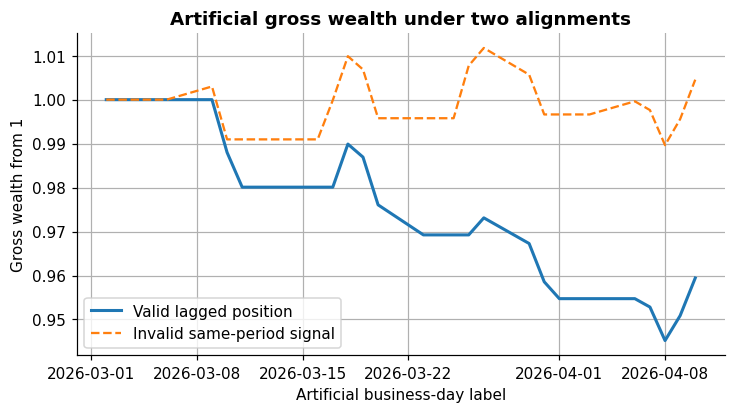

In [15]:
bt["invalid_same_period_return"] = (bt["signal_at_close"] * bt["asset_return"]).fillna(0.0)
bt["invalid_same_period_wealth"] = (1 + bt["invalid_same_period_return"]).cumprod()
bt["return_difference"] = bt["invalid_same_period_return"] - bt["strategy_return_gross"]

difference_rows = bt.index[~np.isclose(bt["return_difference"], 0.0)]
first_difference = difference_rows[0]
first_difference_position = bt.index.get_loc(first_difference)
alignment_preview = bt.iloc[
    max(0, first_difference_position - 2) : first_difference_position + 3
][["asset_return", "signal_at_close", "position", "strategy_return_gross", "invalid_same_period_return", "return_difference"]]
display(alignment_preview.style.format("{:.2%}").set_caption("First valid-versus-invalid return difference"))

alignment_summary = pd.Series(
    {
        "first_different_date": first_difference,
        "different_rows": int(len(difference_rows)),
        "valid_terminal_wealth": bt["strategy_wealth_gross"].iloc[-1],
        "invalid_terminal_wealth": bt["invalid_same_period_wealth"].iloc[-1],
    },
    name="Value",
)
display(alignment_summary.to_frame())

figure, axis = plt.subplots()
axis.plot(bt.index, bt["strategy_wealth_gross"], label="Valid lagged position", linewidth=2)
axis.plot(bt.index, bt["invalid_same_period_wealth"], label="Invalid same-period signal", linestyle="--")
axis.set_title("Artificial gross wealth under two alignments")
axis.set_xlabel("Artificial business-day label")
axis.set_ylabel("Gross wealth from 1")
axis.legend()
show_figure_with_alt_text(figure, "Two artificial gross-wealth lines compare a valid lagged position with an invalid same-period signal; the lines diverge after the first available signal.")

assert len(difference_rows) > 0
assert not np.isclose(alignment_summary["valid_terminal_wealth"], alignment_summary["invalid_terminal_wealth"])

### Interpret the output


The first difference occurs only after a signal becomes available, but the invalid column uses that signal one interval too early. The wealth paths diverge because different returns are attributed to exposure.

The direction and size of the endpoint difference belong only to this fixed artificial path. The reason for rejection is the impossible time order, not whether the invalid wealth is higher.


### Discussion questions

1. At the first differing date in the output, name the prices defining `asset_return`, the time when `signal_at_close` becomes known, and the preceding signal that controls the valid position. Use these facts—not endpoint wealth—to reject the invalid row.
2. Suppose the invalid same-period wealth is lower than the valid wealth on another path. Decide whether the alignment becomes acceptable. Explain why the sign of the distortion is unrelated to the availability violation.

## Issue 15 — How should a missing asset return be handled?


A missing asset return can arise from a missing price, an unmatched interval, a market closure, or an incomplete source. It must not be silently replaced with zero while a nonzero position is held, because zero asserts that the asset value did not change over the intended interval.

The policy below distinguishes two cases. If the strategy is in cash, a missing asset return does not affect that interval's specified zero cash return. If the strategy is exposed, the gross strategy return remains unresolved and the ledger stops before compounding through it.

This rule preserves the difference between no asset observation and an observed zero return.


#### Connection to a documented real source


An official exchange calendar can explain some nontrading dates, and a daily report can confirm whether a field is present. Neither source authorizes forward filling or zero filling. The treatment depends on the intended interval and source evidence.


### Before running the example


Predict the strategy-return status for two missing asset returns: one while position is 0 and one while position is 1. Explain why only the cash row may have a resolved zero strategy return under the stated policy.

In [16]:
missing_demo = pd.DataFrame(
    {
        "position": [0.0, 1.0, 1.0, 0.0],
        "asset_return": [np.nan, np.nan, 0.02, -0.01],
    },
    index=pd.Index(["Cash and missing", "Long and missing", "Long and observed", "Cash and observed"], name="Case"),
)
missing_demo["strategy_return_under_policy"] = np.where(
    missing_demo["position"].eq(0.0),
    0.0,
    missing_demo["asset_return"],
)
missing_demo["status"] = np.where(
    missing_demo["strategy_return_under_policy"].isna(),
    "Stop: exposed return unresolved",
    "Resolved under stated rule",
)
display(missing_demo.style.format({"asset_return": "{:.2%}", "strategy_return_under_policy": "{:.2%}"}).set_caption("Missing-return policy depends on exposure"))

assert missing_demo.loc["Cash and missing", "strategy_return_under_policy"] == 0.0
assert pd.isna(missing_demo.loc["Long and missing", "strategy_return_under_policy"])
assert missing_demo.loc["Long and observed", "strategy_return_under_policy"] == 0.02

,position,asset_return,strategy_return_under_policy,status
Case,,,,
Cash and missing,0.000000,nan%,0.00%,Resolved under stated rule
Long and missing,1.000000,nan%,nan%,Stop: exposed return unresolved
Long and observed,1.000000,2.00%,2.00%,Resolved under stated rule
Cash and observed,0.000000,-1.00%,0.00%,Resolved under stated rule


### Interpret the output


The missing return is resolved as zero only when the specified portfolio is in zero-return cash. The long-and-missing case remains unresolved because the held asset's interval return is unknown. Compounding must stop or the source interval must be repaired.

Forward filling a price may define a different longer holding interval rather than recover the missing daily interval. That decision requires an explicit interval audit.


### Discussion questions

1. A missing price occurs while the strategy is long. Compare zero filling, forward filling, dropping the row, and stopping the ledger. For each choice, state the return interval it claims to represent and decide which choices are defensible without additional source evidence.
2. A market holiday appears as a missing row rather than a missing value. Explain how the next observed close-to-close return differs from an ordinary one-session return and what calendar label must accompany the result before it is combined with other assets.

## Issue 16 — What does the final row mean, and is liquidation required?


The final row closes the observed return interval but may leave a nonzero position. Reporting that position and forcing a sale are different terminal conventions. A forced liquidation creates an additional trade at a boundary for which a price, execution rule, and later cost treatment must be stated.

Week 4 reports the position held during the final observed return and does not append a liquidation. This avoids inventing an execution outside the displayed sample. If an assignment requires terminal cash, the extra boundary must be added explicitly.

Comparisons must use the same terminal convention because trade counts and later costs can change even when gross wealth through the final observed return does not.


#### Connection to a documented real source


Exchange rules can identify available trading sessions after the sample, but they do not require a backtest to liquidate. The analyst must state whether the evaluation ends with an open holding or with a separately modeled closing trade.


### Before running the example


Predict the trade count under two conventions when the final observed position is 1: report the open position, or append a terminal cash row. State whether gross wealth through the last observed asset return changes before costs.

In [17]:
terminal_position = float(bt["position"].iloc[-1])
observed_changes = int((bt["absolute_trade"] > 0).sum())

terminal_comparison = pd.DataFrame(
    [
        {
            "Convention": "Report final position",
            "Final reported position": terminal_position,
            "Additional terminal trade": 0.0,
            "Total position changes": observed_changes,
            "Gross wealth through last observed return": bt["strategy_wealth_gross"].iloc[-1],
        },
        {
            "Convention": "Append liquidation to cash",
            "Final reported position": 0.0,
            "Additional terminal trade": abs(0.0 - terminal_position),
            "Total position changes": observed_changes + int(terminal_position != 0.0),
            "Gross wealth through last observed return": bt["strategy_wealth_gross"].iloc[-1],
        },
    ]
)
display(terminal_comparison.style.format({"Gross wealth through last observed return": "{:.6f}"}).hide(axis="index").set_caption("Two terminal-boundary conventions"))

assert terminal_comparison["Gross wealth through last observed return"].nunique() == 1
assert terminal_comparison.loc[1, "Additional terminal trade"] == abs(terminal_position)

Convention,Final reported position,Additional terminal trade,Total position changes,Gross wealth through last observed return
Report final position,1.000000,0.000000,7,0.959434
Append liquidation to cash,0.000000,1.000000,8,0.959434


### Interpret the output


Both conventions have the same gross wealth through the last observed return. If the final position is long, the liquidation convention adds one position change; if it is already cash, it adds none. Week 6 would attach a cost only after a specific terminal execution boundary is supplied.

The open position is not a hidden gain or loss after the sample. It is simply the documented terminal state at the chosen evaluation boundary.


### Discussion questions

1. Two strategies end with the same gross wealth, but one is long and one is cash. Explain why their results are not fully comparable if a report requires terminal cash and costs are later added. Identify the extra event required for the long strategy.
2. A team appends a zero-return liquidation row and counts a trade but supplies no execution price or time. Decide which parts of the record are accounting assumptions and which real-market claims remain unsupported.

## Issue 17 — What does a gross buy-and-hold benchmark add?


A buy-and-hold benchmark keeps position 1 after the stated initial boundary and compounds the same asset returns. It answers what continuous exposure to the same artificial price path would have produced before costs. It does not validate the strategy, identify a risk-adjusted winner, or establish statistical significance.

The strategy and benchmark must use the same return rows and gross convention. Their initial positions may differ by design, so the starting boundary must be stated.

Week 6 will add cash, rule-based, equal-weighted, and cost-aware comparisons. Week 7 will add risk and uncertainty measures.


#### Connection to a documented real source


TWSE closing prices could supply the same documented return intervals to two historical methods after course data are approved. The exchange does not designate buy-and-hold as the correct comparator or validate an analyst's signal.


### Before running the example


Predict whether the gross strategy and gross buy-and-hold wealth paths must have the same endpoint on this artificial sample. Identify the common input and the different exposure rule.

Method,Return rows,Long intervals,Position changes,Gross terminal wealth
Week 4 lagged long-or-cash rule,30,14,7,0.959434
Artificial buy and hold,30,29,1,1.042053


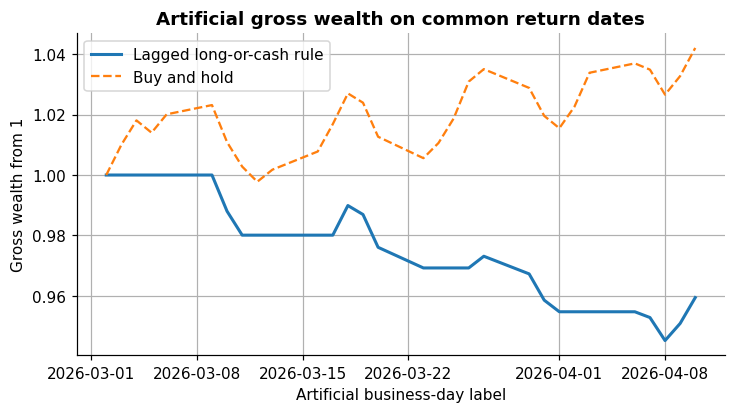

In [18]:
bt["buy_hold_return_gross"] = bt["asset_return"].fillna(0.0)
bt["buy_hold_wealth_gross"] = (1 + bt["buy_hold_return_gross"]).cumprod()

benchmark_summary = pd.DataFrame(
    [
        {
            "Method": "Week 4 lagged long-or-cash rule",
            "Return rows": len(bt),
            "Long intervals": int(bt["position"].sum()),
            "Position changes": int((bt["absolute_trade"] > 0).sum()),
            "Gross terminal wealth": bt["strategy_wealth_gross"].iloc[-1],
        },
        {
            "Method": "Artificial buy and hold",
            "Return rows": len(bt),
            "Long intervals": int(bt["asset_return"].notna().sum()),
            "Position changes": 1,
            "Gross terminal wealth": bt["buy_hold_wealth_gross"].iloc[-1],
        },
    ]
)
display(benchmark_summary.style.format({"Gross terminal wealth": "{:.6f}"}).hide(axis="index").set_caption("Gross comparison on common artificial asset-return rows"))

figure, axis = plt.subplots()
axis.plot(bt.index, bt["strategy_wealth_gross"], label="Lagged long-or-cash rule", linewidth=2)
axis.plot(bt.index, bt["buy_hold_wealth_gross"], label="Buy and hold", linestyle="--")
axis.set_title("Artificial gross wealth on common return dates")
axis.set_xlabel("Artificial business-day label")
axis.set_ylabel("Gross wealth from 1")
axis.legend()
show_figure_with_alt_text(figure, "Two artificial gross wealth lines compare the lagged long-or-cash rule with continuous buy-and-hold exposure on the same return dates.")

assert benchmark_summary["Return rows"].nunique() == 1
assert np.isclose(bt["buy_hold_wealth_gross"].iloc[-1], bt["Close"].iloc[-1] / bt["Close"].iloc[0])

### Interpret the output


The two paths share the artificial asset returns but hold different exposures. Their endpoints therefore need not match. The table also shows different counts of long intervals and position changes.

No ranking is justified from one gross artificial path. Costs, cash return, drawdown, risk, and uncertainty are absent, and the path was not sampled from an approved market dataset.


### Discussion questions

1. The trading rule has higher gross terminal wealth than buy and hold on the artificial path but changes position ten times. List the missing Week 6–7 evidence needed before arguing that the rule is preferable.
2. A benchmark starts one date later than the strategy because its first return was dropped. Explain why the endpoint comparison is no longer on common intervals and describe the exact date intersection that must be rebuilt.

## Issue 18 — How do specified holdings produce a portfolio return?


A backtest may hold more than one asset. Given beginning-of-interval asset values or weights, portfolio return is the value-weighted sum of same-interval asset returns. The asset labels, beginning boundary, ending boundary, and return convention must match.

This issue uses stated artificial holdings rather than selecting weights. Weight selection begins in Week 8. The two positions are held without rebalancing during one interval, so their ending values determine both portfolio return and weight drift.

No trade or cost is attached because the beginning holdings are treated as given.


#### Connection to a documented real source


Separate TWSE daily reports for securities 2330 and 2317 can provide same-date closing prices after field and unit checks. The exchange reports supply the prices, not the classroom holdings or a recommendation to combine the securities.


### Before running the example


Beginning values are 70 and 30. Asset returns are 2% and −1%. Predict the portfolio return, ending total value, and ending weights without rebalancing.

In [19]:
holdings_case = pd.DataFrame(
    {
        "Beginning value": [70.0, 30.0],
        "Same-interval asset return": [0.02, -0.01],
    },
    index=pd.Index(["Artificial Asset A", "Artificial Asset B"], name="Asset"),
)
holdings_case["Beginning weight"] = holdings_case["Beginning value"] / holdings_case["Beginning value"].sum()
holdings_case["Return contribution"] = holdings_case["Beginning weight"] * holdings_case["Same-interval asset return"]
holdings_case["Ending value"] = holdings_case["Beginning value"] * (1 + holdings_case["Same-interval asset return"])
holdings_case["Ending weight"] = holdings_case["Ending value"] / holdings_case["Ending value"].sum()
portfolio_return_one_interval = holdings_case["Return contribution"].sum()
portfolio_return_from_values = holdings_case["Ending value"].sum() / holdings_case["Beginning value"].sum() - 1

display(holdings_case.style.format({
    "Beginning weight": "{:.2%}",
    "Same-interval asset return": "{:.2%}",
    "Return contribution": "{:.2%}",
    "Ending weight": "{:.2%}",
}).set_caption("Specified artificial holdings over one common interval"))
display(pd.Series({"Portfolio return from contributions": portfolio_return_one_interval, "Portfolio return from total values": portfolio_return_from_values, "Ending total value": holdings_case["Ending value"].sum()}, name="Value").to_frame())

assert np.isclose(portfolio_return_one_interval, 0.7 * 0.02 + 0.3 * -0.01)
assert np.isclose(portfolio_return_one_interval, portfolio_return_from_values)
assert np.isclose(holdings_case["Ending weight"].sum(), 1.0)

,Beginning value,Same-interval asset return,Beginning weight,Return contribution,Ending value,Ending weight
Asset,,,,,,
Artificial Asset A,70.000000,2.00%,70.00%,1.40%,71.400000,70.62%
Artificial Asset B,30.000000,-1.00%,30.00%,-0.30%,29.700000,29.38%


,Value
Portfolio return from contributions,0.011
Portfolio return from total values,0.011
Ending total value,101.100


### Interpret the output


The portfolio return is 1.1%, and total value rises from 100 to 101.1. Asset A's ending weight exceeds 70% because it earned the higher return. Resetting the portfolio to 70/30 for the next interval would require a separate rebalance trade.

The arithmetic requires common intervals. Combining a two-day return for one asset with a one-day return for another would not represent one portfolio holding interval.


### Discussion questions

1. Starting from the output's ending values, calculate the trades required to restore 70/30 before a second interval. Identify the target values, signed trades, and why Week 4 must not call the restoration costless once Week 6 begins.
2. Asset B lacks an ending price on the common date. Compare dropping B, carrying its old value forward, and postponing the portfolio return. For each choice, state what portfolio the result now represents and which source evidence is missing.

## Issue 19 — What record makes the backtest reproducible?


Reproducibility requires more than saving code. Another person needs the data boundary, field definitions, feature and signal rules, timing assumptions, position mapping, return interval, cash rule, terminal rule, package versions, and the scope of conclusions.

The concise record below is populated from the actual Week 4 objects rather than from memory. Hashes or repository commits can later identify an exact file version, but they do not replace the financial specification.

Unresolved real-data facts remain marked as pending. A reproducible artificial ledger is not automatically a reproducible market backtest.


#### Connection to a documented real source


TWSE documents market fields and sessions, and official Python documentation specifies software behavior. A real reproduction record must cite both kinds of source where relevant and retain the analyst-created rules separately.


### Before running the example


Predict which fields could be reconstructed from the ledger alone and which require the written strategy specification or external source documentation.

In [20]:
backtest_record = pd.DataFrame(
    [
        ("Data origin", "Fixed artificial path defined in this notebook"),
        ("Index", f"{bt.index.min().date()} to {bt.index.max().date()}, {len(bt)} artificial business-day labels"),
        ("Price field", "Artificial Close; positive decimal price units"),
        ("Return formula", "Close[t] / Close[t-1] - 1"),
        ("Feature", "Five-session simple price momentum"),
        ("Signal", "1 if momentum > 0; 0 otherwise; missing before feature exists"),
        ("Position", "Previous row's signal; initial cash"),
        ("Execution boundary", "Before the next artificial return interval"),
        ("Costs", "Zero; all Week 4 results are gross"),
        ("Terminal rule", "Report final position; no forced liquidation"),
        ("Software", f"Python {platform.python_version()}, numpy {np.__version__}, pandas {pd.__version__}"),
        ("Real provider release and execution evidence", "Pending; not represented by the artificial path"),
        ("Unsupported conclusion", "Predictability, real fillability, net profitability, or future performance"),
    ],
    columns=["Record field", "Recorded value"],
)
display(backtest_record.style.hide(axis="index").set_caption("Concise Week 4 reproduction record"))

required_record_fields = {"Data origin", "Return formula", "Signal", "Position", "Execution boundary", "Costs", "Terminal rule", "Unsupported conclusion"}
assert required_record_fields.issubset(set(backtest_record["Record field"]))

Record field,Recorded value
Data origin,Fixed artificial path defined in this notebook
Index,"2026-03-02 to 2026-04-10, 30 artificial business-day labels"
Price field,Artificial Close; positive decimal price units
Return formula,Close[t] / Close[t-1] - 1
Feature,Five-session simple price momentum
Signal,1 if momentum > 0; 0 otherwise; missing before feature exists
Position,Previous row's signal; initial cash
Execution boundary,Before the next artificial return interval
Costs,Zero; all Week 4 results are gross
Terminal rule,Report final position; no forced liquidation


### Interpret the output


The ledger can reveal dates, values, and formulas already stored in columns, but it cannot reveal why those fields were selected, which execution event was intended, or what the source provider meant unless those facts are written separately.

Marking real provider and execution evidence as pending prevents an artificial teaching path from being presented as a completed real-market study.


### Discussion questions

1. Another student receives only the final wealth series. List the minimum additional columns and written assumptions required to reconstruct the Week 4 ledger. Explain which timing error could remain invisible even if the wealth values are reproduced.
2. A notebook contains an exact Git commit hash but no field definition or execution rule. Decide which parts of reproducibility the hash establishes and which financial claims remain impossible to audit.

## Issue 20 — Can the complete ledger support its stated conclusion and no more?


The final audit combines scope, timing, accounting, and conclusion checks. It confirms that Week 3 signals were lagged, positions and trades reconcile, gross returns use same-interval asset returns, wealth compounds correctly, and no transaction-cost or full performance claim has been inserted.

A passed audit supports one narrow statement: the fixed artificial long-or-cash ledger is internally consistent under its written assumptions. It cannot support a claim about real predictability, execution, net profitability, risk-adjusted superiority, or future performance.

Week 5 may replace the rule output with model predictions, but it must preserve every boundary and identity established here.


#### Connection to a documented real source


Official market, data, and software sources each support limited parts of a real workflow. None can certify the final strategy conclusion. The analyst must show that the ledger's evidence, assumptions, and claim boundary are consistent.


### Before running the example


Predict which checks remain true if the strategy loses money on the artificial path. Explain why accounting validity must not depend on the sign of terminal return.

In [21]:
complete_ledger_columns = [
    "Close", "asset_return", "mom_5", "signal_at_close", "position",
    "signed_trade", "absolute_trade", "strategy_return_gross",
    "strategy_wealth_gross", "buy_hold_wealth_gross",
]
complete_ledger = bt[complete_ledger_columns].copy()
display(complete_ledger.tail(12).style.format({
    "asset_return": "{:.2%}",
    "mom_5": "{:.2%}",
    "strategy_return_gross": "{:.2%}",
    "strategy_wealth_gross": "{:.6f}",
    "buy_hold_wealth_gross": "{:.6f}",
}).set_caption("Final rows of the complete artificial gross ledger"))

scope_audit = pd.DataFrame(
    [
        ("Dates sorted and unique", bt.index.is_monotonic_increasing and bt.index.is_unique),
        ("Positions are long or cash", set(bt["position"].unique()).issubset({0.0, 1.0})),
        ("Available positions equal preceding signals", np.allclose(position_residual, 0.0)),
        ("Trades reconcile with position changes", np.allclose(trade_residual, 0.0)),
        ("Gross returns reconcile", np.allclose(return_residual, 0.0)),
        ("Wealth recursion reconciles", np.allclose(wealth_residual, 0.0)),
        ("No cost or net-return column is claimed", not any("cost" in c.lower() or "net" in c.lower() for c in complete_ledger.columns)),
        ("No annualized performance statistic is claimed", not any(token in complete_ledger.columns for token in ["sharpe", "sortino", "maximum_drawdown"])),
    ],
    columns=["Audit statement", "Passed"],
)
display(scope_audit.style.hide(axis="index").set_caption("Week 4 timing, accounting, and scope audit"))

final_summary = pd.Series(
    {
        "observations": len(bt),
        "available_signals": int(bt["signal_at_close"].notna().sum()),
        "long_intervals": int(bt["position"].sum()),
        "position_changes": int((bt["absolute_trade"] > 0).sum()),
        "gross_terminal_wealth": bt["strategy_wealth_gross"].iloc[-1],
        "final_position": bt["position"].iloc[-1],
    },
    name="Value",
)
display(final_summary.to_frame())
assert scope_audit["Passed"].all()

,Close,asset_return,mom_5,signal_at_close,position,signed_trade,absolute_trade,strategy_return_gross,strategy_wealth_gross,buy_hold_wealth_gross
Date,,,,,,,,,,
2026-03-26 00:00:00,103.091746,1.20%,0.68%,1.000000,0.000000,0.000000,0.000000,0.00%,0.969239,1.030917
2026-03-27 00:00:00,103.504113,0.40%,2.21%,1.000000,1.000000,1.000000,1.000000,0.40%,0.973116,1.035041
2026-03-30 00:00:00,102.883088,-0.60%,2.31%,1.000000,1.000000,0.000000,0.000000,-0.60%,0.967277,1.028831
2026-03-31 00:00:00,101.957140,-0.90%,0.89%,1.000000,1.000000,0.000000,0.000000,-0.90%,0.958571,1.019571
2026-04-01 00:00:00,101.549312,-0.40%,-0.31%,0.000000,1.000000,0.000000,0.000000,-0.40%,0.954737,1.015493
2026-04-02 00:00:00,102.260157,0.70%,-0.81%,0.000000,0.000000,-1.000000,1.000000,0.00%,0.954737,1.022602
2026-04-03 00:00:00,103.385019,1.10%,-0.12%,0.000000,0.000000,0.000000,0.000000,0.00%,0.954737,1.033850
2026-04-06 00:00:00,103.695174,0.30%,0.79%,1.000000,0.000000,0.000000,0.000000,0.00%,0.954737,1.036952
2026-04-07 00:00:00,103.487783,-0.20%,1.50%,1.000000,1.000000,1.000000,1.000000,-0.20%,0.952828,1.034878


Audit statement,Passed
Dates sorted and unique,True
Positions are long or cash,True
Available positions equal preceding signals,True
Trades reconcile with position changes,True
Gross returns reconcile,True
Wealth recursion reconciles,True
No cost or net-return column is claimed,True
No annualized performance statistic is claimed,True


,Value
observations,30.000000
available_signals,25.000000
long_intervals,14.000000
position_changes,7.000000
gross_terminal_wealth,0.959434
final_position,1.000000


### Interpret the output


All timing, accounting, and scope checks pass for the fixed artificial ledger. The summary describes observations, signals, exposure, changes in exposure, gross terminal wealth, and the final position. None of these values is a real-market estimate.

The absence of cost, net-return, Sharpe, Sortino, and drawdown columns is intentional. Those omissions identify what Weeks 6 and 7 must add rather than weaknesses to conceal.


### Discussion questions

1. Suppose the same ledger passes every accounting check but uses a provider field whose publication time is unknown. Decide which internal conclusion remains valid and which historical-trading conclusion must be withheld.
2. A team adds a model in Week 5 and reports higher prediction accuracy. Identify every Week 4 column and identity that must remain unchanged before any portfolio return comparison is accepted.

# Independent practice issues

The first three exercises isolate one decision each. Case 4 combines the full Week 4 chain. Starter cells load and display new inputs but do not contain the requested solutions. Preserve the prediction written before coding, the completed ledger, passed checks, and the conclusion boundary.

## Practice issue 1 — Repair a signal-to-position alignment

The displayed input contains an after-close signal and the asset return ending on each row. Before coding, predict the first row that may hold a long position.

Create `valid_position`, `signed_trade`, `absolute_trade`, `gross_strategy_return`, and `gross_wealth`. Initialize unavailable preceding signals to cash. Then create a separate invalid same-row implementation and identify the first differing return. Your explanation must use the signal and return times rather than the better endpoint.

Required checks: valid position equals the preceding signal wherever available; permitted positions are `{0, 1}`; gross return equals position times same-interval return; wealth equals direct compounding; and at least one valid return differs from the invalid return.

In [22]:
practice_1 = pd.DataFrame(
    {
        "asset_return": [np.nan, 0.01, -0.02, 0.03, 0.01, -0.01, 0.02],
        "signal_at_close": [np.nan, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0],
    },
    index=pd.date_range("2026-06-01", periods=7, freq="D"),
)
display(practice_1.style.format({"asset_return": "{:.2%}"}).set_caption("Practice 1 input; add the requested columns without changing these values"))
print("Input loaded. Write the predicted first long row before constructing positions.")

,asset_return,signal_at_close
2026-06-01 00:00:00,nan%,nan
2026-06-02 00:00:00,1.00%,1.000000
2026-06-03 00:00:00,-2.00%,0.000000
2026-06-04 00:00:00,3.00%,1.000000
2026-06-05 00:00:00,1.00%,1.000000
2026-06-06 00:00:00,-1.00%,0.000000
2026-06-07 00:00:00,2.00%,1.000000


Input loaded. Write the predicted first long row before constructing positions.


## Practice issue 2 — Decide whether a missing return can be resolved

The displayed ledger fragment contains one missing asset return while long and one missing asset return while in cash. Apply the Week 4 missing-return policy without modifying the source column.

Create a resolved-or-stop status, calculate only the gross returns supported by the stated policy, and explain what additional price or calendar evidence would be needed for the unresolved row. Do not forward fill, drop, or replace the exposed missing return unless you first redefine and document the holding interval.

Required checks: the cash-and-missing case produces zero under the specified zero cash return; the long-and-missing case remains unresolved; and every observed long return passes through unchanged.

In [23]:
practice_2 = pd.DataFrame(
    {
        "position": [0.0, 1.0, 1.0, 0.0, 1.0],
        "asset_return": [np.nan, 0.015, np.nan, -0.005, 0.02],
    },
    index=pd.Index(["A", "B", "C", "D", "E"], name="Row"),
)
display(practice_2.style.format({"asset_return": "{:.2%}"}).set_caption("Practice 2 missing-return cases"))
print("Input loaded. Preserve the missing values until the exposure-dependent policy is applied.")

,position,asset_return
Row,,
A,0.000000,nan%
B,1.000000,1.50%
C,1.000000,nan%
D,0.000000,-0.50%
E,1.000000,2.00%


Input loaded. Preserve the missing values until the exposure-dependent policy is applied.


## Practice issue 3 — Compare terminal conventions

The displayed position sequence ends long. First calculate position changes under the Week 4 convention that reports the final position without liquidation. Then append a separate terminal cash boundary and calculate the additional position change.

Keep gross wealth through the final observed asset return unchanged in both versions. Explain which execution time, price, and Week 6 cost evidence would be needed before the appended liquidation can be treated as a real trade.

Required checks: the appended row changes only the terminal position and trade count before costs; no additional asset return is invented; and both versions clearly state their terminal position.

In [24]:
practice_3 = pd.DataFrame(
    {
        "position": [0.0, 1.0, 1.0, 0.0, 1.0],
        "gross_strategy_return": [0.0, 0.01, -0.02, 0.0, 0.03],
    },
    index=pd.date_range("2026-07-06", periods=5, freq="D"),
)
display(practice_3.style.format({"gross_strategy_return": "{:.2%}"}).set_caption("Practice 3 observed ledger ending with an open long position"))
print("Input loaded. Create two terminal conventions without adding an unobserved asset return.")

,position,gross_strategy_return
2026-07-06 00:00:00,0.000000,0.00%
2026-07-07 00:00:00,1.000000,1.00%
2026-07-08 00:00:00,1.000000,-2.00%
2026-07-09 00:00:00,0.000000,0.00%
2026-07-10 00:00:00,1.000000,3.00%


Input loaded. Create two terminal conventions without adding an unobserved asset return.


## Case 4 — Build and audit a complete gross ledger

The case supplies 14 artificial closing prices and a separately displayed after-close signal. Treat every row label as one consecutive artificial interval. Do not infer an exchange calendar.

Complete the information listed under preparation, calculate asset returns, shift the signal once to create long-or-cash positions, calculate signed and absolute position changes, gross strategy returns, and gross wealth, and build a gross buy-and-hold benchmark on the same rows. Create an invalid same-period comparison but reject it using time evidence.

Your final audit must identify the first eligible long interval, one entry, one exit, the first valid-versus-invalid difference, the terminal position, and every accounting identity. State one conclusion supported by the artificial ledger and at least four conclusions it cannot support before Weeks 5–7 add prediction models, costs, and performance evidence.

In [25]:
case_4_prices = pd.Series(
    [100.0, 101.0, 102.0, 101.5, 103.0, 104.0, 102.0, 101.0, 103.0, 105.0, 104.0, 106.0, 105.0, 107.0],
    index=pd.bdate_range("2026-08-03", periods=14),
    name="Close",
)
case_4_signal = pd.Series(
    [np.nan, np.nan, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0],
    index=case_4_prices.index,
    name="signal_at_close",
)
case_4_input = pd.concat([case_4_prices, case_4_signal], axis=1)
display(case_4_input.style.set_caption("Case 4 fixed artificial prices and after-close signals"))
print("Case inputs loaded. Preserve the source columns and add the complete Week 4 ledger.")

,Close,signal_at_close
2026-08-03 00:00:00,100.000000,nan
2026-08-04 00:00:00,101.000000,nan
2026-08-05 00:00:00,102.000000,1.000000
2026-08-06 00:00:00,101.500000,1.000000
2026-08-07 00:00:00,103.000000,0.000000
2026-08-10 00:00:00,104.000000,0.000000
2026-08-11 00:00:00,102.000000,1.000000
2026-08-12 00:00:00,101.000000,1.000000
2026-08-13 00:00:00,103.000000,1.000000
2026-08-14 00:00:00,105.000000,0.000000


Case inputs loaded. Preserve the source columns and add the complete Week 4 ledger.


# Terminology reference

| Term | Meaning used in Week 4 |
|---|---|
| signal | Output of a stated rule after its required information is available |
| position | Exposure held during a specified return interval |
| holding | Asset quantity or value carried during an interval |
| entry | Position change from cash to long exposure |
| exit | Position change from long exposure to cash |
| signed position change | Current position minus preceding position |
| absolute position change | Absolute value of the signed position change |
| asset return | Price change of the asset over a stated beginning and ending boundary |
| gross strategy return | Position multiplied by the same-interval asset return before costs |
| gross wealth | Initial wealth compounded by gross strategy returns |
| buy and hold | Continuous exposure to the same asset under a stated starting boundary |
| look-ahead bias | Use of information that was unavailable at the relevant historical decision time |
| terminal position | Exposure reported at the final observed boundary |

These meanings apply to the documented artificial lesson. A real implementation must add provider definitions, a market calendar, an executable order and price convention, and later cost and performance evidence.

# Troubleshooting reference

| Symptom | First check | Safe next action |
|---|---|---|
| Position equals the same-row signal | Compare signal time with the return ending on that row | Restore the preceding-signal relation before calculating returns |
| First position is long despite missing signal history | Inspect initialization and `fillna` order | Keep signal missing and apply the written initial-cash rule to position only |
| Trade count equals invested-day count | Compare `position` with `position.diff()` | Count exposure changes separately from holding intervals |
| Strategy return differs from asset return while long | Compare indexes and same-row values | Align position and return to the identical interval before multiplication |
| Strategy return is nonzero while in cash | Inspect cash return and position mapping | Apply the specified zero cash return without altering the asset-return column |
| Wealth endpoint does not equal direct compounding | Locate the first recursive residual | Repair the return or wealth row before interpreting the endpoint |
| Missing asset return becomes zero while long | Search for fills before multiplication | Restore missing and resolve the source interval or stop the ledger |
| Invalid and valid alignments are identical | Confirm that signals change and the two formulas use different columns | Display the first available signal and adjacent returns |
| Terminal trade appears without a boundary | Inspect the terminal convention | Remove it or add a separately documented execution event |
| Portfolio component returns use different intervals | Display beginning and ending boundaries for every asset | Rebuild common endpoints before combining holdings |
| Gross result is described as net | Search for cost, spread, and slippage assumptions | Relabel as gross and postpone the net claim to Week 6 |
| A passing assertion is treated as investment evidence | Read the exact identity tested | Limit the conclusion to internal consistency under stated assumptions |

# Optional extensions and sources

## Optional extensions

These activities are not required for Week 4 completion:

- add a fractional-position design and write new validation rules without calling it long or cash;
- compare next-open and next-close assumptions using additional artificial fields while preserving different holding intervals;
- append a terminal liquidation boundary and leave its cost pending for Week 6;
- extend the specified-holdings example to three assets after constructing common endpoints; and
- write a function that returns the first failed accounting identity and its row.

## Official software references

- [`pandas.DataFrame.shift`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html) documents row shifting used for the signal-to-position relation.
- [`pandas.Series.diff`](https://pandas.pydata.org/docs/reference/api/pandas.Series.diff.html) documents position differences.
- [`pandas.Series.pct_change`](https://pandas.pydata.org/docs/reference/api/pandas.Series.pct_change.html) documents fractional price change.
- [`pandas.Series.cumprod`](https://pandas.pydata.org/docs/reference/api/pandas.Series.cumprod.html) documents cumulative products used for wealth.
- [`numpy.isclose`](https://numpy.org/doc/stable/reference/generated/numpy.isclose.html) documents numerical comparison used by accounting checks.

## Financial and market references

- Campbell, J. Y., Lo, A. W., & MacKinlay, A. C. (1997). *The Econometrics of Financial Markets*. Princeton University Press, Chapter 1, “Prices, Returns, and Compounding,” pp. 9–13. [Publisher chapter record](https://doi.org/10.1515/9781400830213-005).
- The Taiwan Stock Exchange [daily trading report for security 2330](https://www.twse.com.tw/exchangeReport/STOCK_DAY?date=20200224&response=html&stockNo=2330) supplies the two closing-price observations used only for the interval-reading example.
- The corresponding TWSE [daily trading report for security 2317](https://www.twse.com.tw/exchangeReport/STOCK_DAY?date=20200224&response=html&stockNo=2317) illustrates a second official asset record for the specified-holdings discussion; no real two-asset strategy is calculated in the required notebook.
- The TWSE [Trading Mechanism Introduction](https://www.twse.com.tw/en/products/system/trading.html) states regular-session order and trading boundaries used to distinguish observation, decision, and execution events.
- TWSE [Information Services](https://www.twse.com.tw/en/products/information/information.html) distinguishes real-time, delayed, after-market, and historical information.
- The U.S. Securities and Exchange Commission's Investor.gov [compound interest calculator and explanation](https://www.investor.gov/financial-tools-calculators/calculators/compound-interest-calculator) provides general compound-growth context; the notebook's return sequence and strategy remain instructor-created.

The textbook source supports standard price-return and compounding notation. Exchange pages support only the market fields and session boundaries explicitly identified. Official software pages support calculation behavior. None of these sources verifies the artificial signal, execution assumption, gross wealth, or future investment value.

# Completion evidence

## Required submission

Submit this completed notebook or an exported report containing:

1. every worked-example cell with visible table or figure output and passed checks;
2. one written response selected from the two discussion questions for each of Issues 1–20, plus any additional responses designated during class;
3. predictions, completed calculations, revisions, and checks for Practice issues 1–3 and Case 4;
4. the requested backtest information from the preparation section completed once for Case 4;
5. one supported conclusion about the artificial ledger and at least four conclusions it cannot support.

## Completion conditions

Week 4 is complete when another student can:

- identify the beginning and ending boundaries of every return;
- trace one date from Week 3 signal through position, trade, gross return, and wealth;
- reproduce every entry, exit, position change, and accounting identity;
- identify the first invalid same-period return and reject it from time evidence;
- distinguish unavailable signal history, zero signal, initial cash, missing asset return, and observed zero return;
- state the final position and terminal convention;
- reproduce the specified-holdings portfolio return over a common interval; and
- explain why the notebook contains no net return, complete performance evaluation, or real-market investment claim.

The specification, ledger, timing comparison, and audit support the backtest evidence required for [Report 1](../10/week10_main.md). They do not change report weights or add a grading criterion.

## Exit evidence

Complete these statements:

```text
My signal is known at ______.
The position at row t is controlled by ______.
That position earns the asset return from ______ to ______.
One entry and one exit in my ledger occur at ______ and ______.
The terminal position is ______ under the rule ______.
The gross ledger supports ______ but cannot support ______.
```

An internally consistent gross backtest implements the stated historical boundaries and accounting. It does not establish realistic execution, net profitability, risk-adjusted superiority, statistical certainty, or future performance.